# 🎬 Nhận dạng hành động từ video ngắn – UCF101

**Mô hình:** ResNet18 (trích đặc trưng từng frame) → LSTM → Fully Connected

**Dataset:** UCF101 với cấu trúc đã chia sẵn:
```
archive/
├── train/   ← 101 lớp
├── val/     ← 101 lớp
└── test/    ← 101 lớp
```
> 📌 Notebook đơn giản, dễ đọc, phù hợp cho sinh viên học Deep Learning.

## Bước 1: Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive đã được mount thành công!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive đã được mount thành công!


## Bước 2: Cài đặt thư viện

In [4]:
!pip install -q opencv-python-headless
print('✅ Thư viện đã sẵn sàng!')

✅ Thư viện đã sẵn sàng!


## Bước 3: Import thư viện

In [5]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import f1_score

# Đặt seed để kết quả có thể tái lập
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Đang dùng thiết bị: {device}')

✅ Đang dùng thiết bị: cuda


## Bước 4: Cấu hình tham số

In [6]:
# ---- Đường dẫn dataset ----
# Dataset đã chia sẵn thành 3 thư mục
DATA_DIR  = '/content/drive/MyDrive/deep/BaoCao/archive'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR   = os.path.join(DATA_DIR, 'val')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

# ---- Chọn 5 lớp để train thử (nhẹ hơn so với 101 lớp) ----
# Tên phải khớp chính xác với tên thư mục con trong archive/train/
SELECTED_CLASSES = [
    'Basketball',
    'BenchPress',
    'Biking',
    'BreastStroke',
    'BoxingPunchingBag'
]

# ---- Tham số model ----
NUM_FRAMES  = 16    # Số frame lấy từ mỗi video
IMAGE_SIZE  = 224   # Resize frame về 224x224 (chuẩn ResNet)
HIDDEN_SIZE = 256   # Kích thước hidden state của LSTM
NUM_LAYERS  = 1     # Số tầng LSTM
NUM_CLASSES = len(SELECTED_CLASSES)  # = 5

# ---- Tham số train ----
BATCH_SIZE    = 4     # Nhỏ để tránh hết RAM GPU trên Colab
EPOCHS        = 10
LEARNING_RATE = 1e-4

# ---- Đường dẫn lưu model tốt nhất ----
SAVE_PATH = '/content/drive/MyDrive/best_model.pth'

print('✅ Cấu hình hoàn tất!')
print(f'   Số lớp     : {NUM_CLASSES}')
print(f'   Số frame   : {NUM_FRAMES}')
print(f'   Batch size : {BATCH_SIZE}')
print(f'   Epochs     : {EPOCHS}')
print()

# Kiểm tra nhanh các thư mục có tồn tại không
for split, path in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    ok = os.path.isdir(path)
    print(f'   {split:5s} → {ok and "✅" or "❌ KHÔNG TÌM THẤY:"}  {path}')

✅ Cấu hình hoàn tất!
   Số lớp     : 5
   Số frame   : 16
   Batch size : 4
   Epochs     : 10

   train → ✅  /content/drive/MyDrive/deep/BaoCao/archive/train
   val   → ✅  /content/drive/MyDrive/deep/BaoCao/archive/val
   test  → ✅  /content/drive/MyDrive/deep/BaoCao/archive/test


## Bước 5: Quét dataset và thống kê

Dataset đã được chia sẵn → không cần `train_test_split`.  
Ta chỉ việc đọc thẳng từ `train/`, `val/`, `test/`.

In [7]:
def scan_split(split_dir, selected_classes):
    """
    Quét một thư mục split (train / val / test).

    Cấu trúc thư mục:
        split_dir/
            ClassName1/
                video1.avi
                video2.avi
            ClassName2/
                ...

    Trả về: list các (video_path, label_idx)
    """
    class_to_idx = {cls: idx for idx, cls in enumerate(selected_classes)}
    samples = []

    for cls in selected_classes:
        cls_dir = os.path.join(split_dir, cls)

        if not os.path.isdir(cls_dir):
            print(f'  ⚠️  Không tìm thấy thư mục: {cls_dir}')
            continue

        # Lấy tất cả file video hợp lệ
        videos = [
            f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.avi', '.mp4', '.mov', '.mkv'))
        ]

        for vid in videos:
            samples.append((os.path.join(cls_dir, vid), class_to_idx[cls]))

    return samples, class_to_idx


# Quét cả 3 split
train_samples, class_to_idx = scan_split(TRAIN_DIR, SELECTED_CLASSES)
val_samples,   _            = scan_split(VAL_DIR,   SELECTED_CLASSES)
test_samples,  _            = scan_split(TEST_DIR,  SELECTED_CLASSES)

# Mapping ngược: số → tên lớp
idx_to_class = {v: k for k, v in class_to_idx.items()}

print('📊 Số video tìm được:')
print(f'   Train : {len(train_samples)}')
print(f'   Val   : {len(val_samples)}')
print(f'   Test  : {len(test_samples)}')
print()

# Thống kê phân bố lớp trong tập train
print('📋 Phân bố video theo lớp (Train):')
train_label_counts = Counter([s[1] for s in train_samples])
for idx in sorted(train_label_counts):
    print(f'   [{idx}] {idx_to_class[idx]:30s}: {train_label_counts[idx]} videos')

📊 Số video tìm được:
   Train : 592
   Val   : 96
   Test  : 101

📋 Phân bố video theo lớp (Train):
   [0] Basketball                    : 196 videos
   [1] BenchPress                    : 120 videos
   [2] Biking                        : 98 videos
   [3] BreastStroke                  : 74 videos
   [4] BoxingPunchingBag             : 104 videos


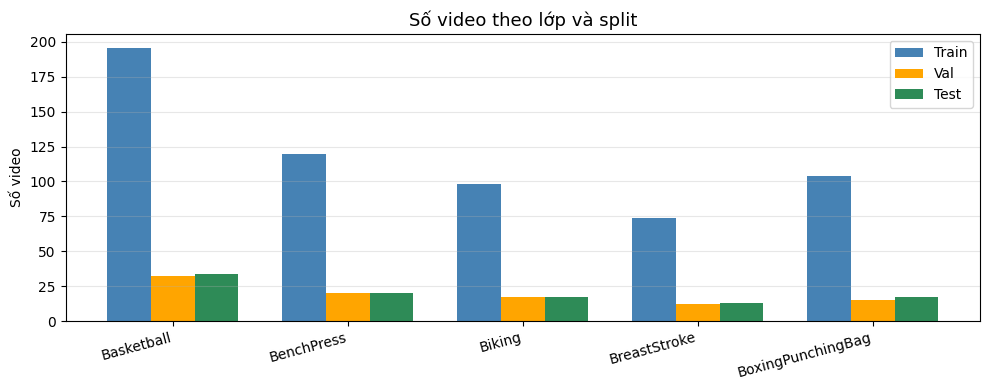

In [8]:
# Vẽ biểu đồ so sánh số video train / val / test theo từng lớp
train_cnt = [Counter([s[1] for s in train_samples]).get(i, 0) for i in range(NUM_CLASSES)]
val_cnt   = [Counter([s[1] for s in val_samples]).get(i, 0)   for i in range(NUM_CLASSES)]
test_cnt  = [Counter([s[1] for s in test_samples]).get(i, 0)  for i in range(NUM_CLASSES)]

x = np.arange(NUM_CLASSES)
w = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w, train_cnt, width=w, label='Train', color='steelblue')
ax.bar(x,     val_cnt,   width=w, label='Val',   color='orange')
ax.bar(x + w, test_cnt,  width=w, label='Test',  color='seagreen')

ax.set_title('Số video theo lớp và split', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(SELECTED_CLASSES, rotation=15, ha='right')
ax.set_ylabel('Số video')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Bước 6: Tạo Dataset và DataLoader

In [9]:
def load_video_frames(video_path, num_frames=16, image_size=224):
    """
    Đọc video, lấy đều `num_frames` frame, trả về tensor (num_frames, 3, H, W).
    Nếu video lỗi hoặc rỗng → trả về tensor toàn 0 (không crash).
    """
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],  # Chuẩn hóa theo ImageNet
            std =[0.229, 0.224, 0.225]
        )
    ])

    cap = cv2.VideoCapture(video_path)
    all_frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # BGR → RGB
        all_frames.append(frame)
    cap.release()

    # Nếu đọc không được frame nào → trả về tensor 0
    if len(all_frames) == 0:
        return torch.zeros(num_frames, 3, image_size, image_size)

    # Lấy đều num_frames chỉ số trải đều từ đầu đến cuối video
    indices = np.linspace(0, len(all_frames) - 1, num_frames, dtype=int)
    frames  = [transform(all_frames[i]) for i in indices]

    return torch.stack(frames)  # (num_frames, 3, H, W)


class VideoDataset(Dataset):
    """Dataset nhận vào list (video_path, label_idx) và trả về frame tensor."""

    def __init__(self, samples, num_frames=16, image_size=224):
        self.samples    = samples
        self.num_frames = num_frames
        self.image_size = image_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        frames = load_video_frames(video_path, self.num_frames, self.image_size)
        return frames, label


# Tạo Dataset
train_dataset = VideoDataset(train_samples, NUM_FRAMES, IMAGE_SIZE)
val_dataset   = VideoDataset(val_samples,   NUM_FRAMES, IMAGE_SIZE)
test_dataset  = VideoDataset(test_samples,  NUM_FRAMES, IMAGE_SIZE)

# Tạo DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('✅ Dataset và DataLoader đã sẵn sàng!')
print(f'   Batch train : {len(train_loader)}')
print(f'   Batch val   : {len(val_loader)}')
print(f'   Batch test  : {len(test_loader)}')

✅ Dataset và DataLoader đã sẵn sàng!
   Batch train : 148
   Batch val   : 24
   Batch test  : 26


## Bước 7: Xây dựng mô hình

```
Video (16 frame)
  → ResNet18 pretrained (bỏ lớp fc)  →  512 chiều / frame
  → LSTM (16 bước, hidden=256)       →  output bước cuối
  → Dropout + Linear                 →  5 lớp
```

In [10]:
class VideoActionModel(nn.Module):
    def __init__(self, num_classes, hidden_size=256, num_lstm_layers=1):
        super().__init__()

        # 1. ResNet18 làm feature extractor
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Giữ lại tất cả trừ lớp fc cuối cùng
        # Output sau avgpool: (batch, 512, 1, 1)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        self.feature_dim = 512

        # Đóng băng ResNet để chỉ train LSTM + FC (nhanh hơn, đủ cho bài tập)
        # Muốn fine-tune ResNet: xóa 2 dòng dưới
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        # 2. LSTM học quan hệ thời gian giữa các frame
        self.lstm = nn.LSTM(
            input_size  = self.feature_dim,  # 512
            hidden_size = hidden_size,       # 256
            num_layers  = num_lstm_layers,
            batch_first = True               # input shape: (batch, seq, feat)
        )

        # 3. Fully Connected để phân loại
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # x: (batch, num_frames, 3, 224, 224)
        B, T, C, H, W = x.shape

        # Gộp batch và frame để đưa qua ResNet cùng lúc
        x    = x.view(B * T, C, H, W)
        feat = self.feature_extractor(x)      # (B*T, 512, 1, 1)
        feat = feat.view(B, T, self.feature_dim)  # (B, T, 512)

        # Qua LSTM
        out, _ = self.lstm(feat)              # (B, T, hidden)

        # Lấy output của frame cuối cùng
        last = out[:, -1, :]                  # (B, hidden)

        # Phân loại
        return self.classifier(last)          # (B, num_classes)


model = VideoActionModel(
    num_classes     = NUM_CLASSES,
    hidden_size     = HIDDEN_SIZE,
    num_lstm_layers = NUM_LAYERS
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('✅ Model đã được tạo!')
print(f'   Tổng tham số     : {total:,}')
print(f'   Tham số trainable: {trainable:,}  ← LSTM + FC (ResNet đóng băng)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 77.4MB/s]


✅ Model đã được tạo!
   Tổng tham số     : 11,966,277
   Tham số trainable: 789,765  ← LSTM + FC (ResNet đóng băng)


## Bước 8: Định nghĩa hàm train và đánh giá

In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Train 1 epoch. Trả về (avg_loss, accuracy)."""
    model.train()
    total_loss = 0
    correct = total = 0

    for i, (frames, labels) in enumerate(loader):
        frames, labels = frames.to(device), labels.to(device)

        optimizer.zero_grad()
        out  = model(frames)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

        if (i + 1) % 10 == 0:
            print(f'     batch {i+1}/{len(loader)} | loss: {loss.item():.4f}')

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Đánh giá model. Trả về (avg_loss, accuracy, macro_f1)."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for frames, labels in loader:
        frames, labels = frames.to(device), labels.to(device)
        out  = model(frames)
        loss = criterion(out, labels)

        total_loss += loss.item()
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc  = np.mean(np.array(all_preds) == np.array(all_labels))
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader), acc, f1


print('✅ Hàm train / evaluate đã sẵn sàng!')

✅ Hàm train / evaluate đã sẵn sàng!


## Bước 9: Train!

In [12]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)
criterion = nn.CrossEntropyLoss()

# Tự giảm LR nếu val_loss không cải thiện sau 3 epoch
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [], 'val_f1': []
}
best_val_loss = float('inf')

print('🚀 Bắt đầu train!')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    print(f'\n📌 Epoch {epoch}/{EPOCHS}')
    print('-' * 40)

    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc, v_f1 = evaluate(model, val_loader, criterion)

    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['train_acc'] .append(t_acc)
    history['val_loss']  .append(v_loss)
    history['val_acc']   .append(v_acc)
    history['val_f1']    .append(v_f1)

    print(f'   Train → Loss: {t_loss:.4f} | Acc: {t_acc*100:.2f}%')
    print(f'   Val   → Loss: {v_loss:.4f} | Acc: {v_acc*100:.2f}% | F1: {v_f1:.4f}')

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'   💾 Đã lưu model tốt nhất! (val_loss={v_loss:.4f})')

print('\n' + '=' * 60)
print('✅ Train hoàn tất!')

🚀 Bắt đầu train!

📌 Epoch 1/10
----------------------------------------
     batch 10/148 | loss: 1.5101
     batch 20/148 | loss: 1.9451
     batch 30/148 | loss: 1.5520
     batch 40/148 | loss: 1.3976
     batch 50/148 | loss: 1.5595
     batch 60/148 | loss: 1.1341
     batch 70/148 | loss: 1.4078
     batch 80/148 | loss: 1.2938
     batch 90/148 | loss: 1.0881
     batch 100/148 | loss: 1.1621
     batch 110/148 | loss: 1.3389
     batch 120/148 | loss: 1.1526
     batch 130/148 | loss: 1.2534
     batch 140/148 | loss: 1.3347
   Train → Loss: 1.3701 | Acc: 44.93%
   Val   → Loss: 0.8490 | Acc: 84.38% | F1: 0.8321
   💾 Đã lưu model tốt nhất! (val_loss=0.8490)

📌 Epoch 2/10
----------------------------------------
     batch 10/148 | loss: 1.0820
     batch 20/148 | loss: 0.8129
     batch 30/148 | loss: 0.9568
     batch 40/148 | loss: 0.6429
     batch 50/148 | loss: 1.1676
     batch 60/148 | loss: 0.7029
     batch 70/148 | loss: 0.9478
     batch 80/148 | loss: 1.4117
     ba

## Bước 10: Vẽ biểu đồ Loss và Accuracy

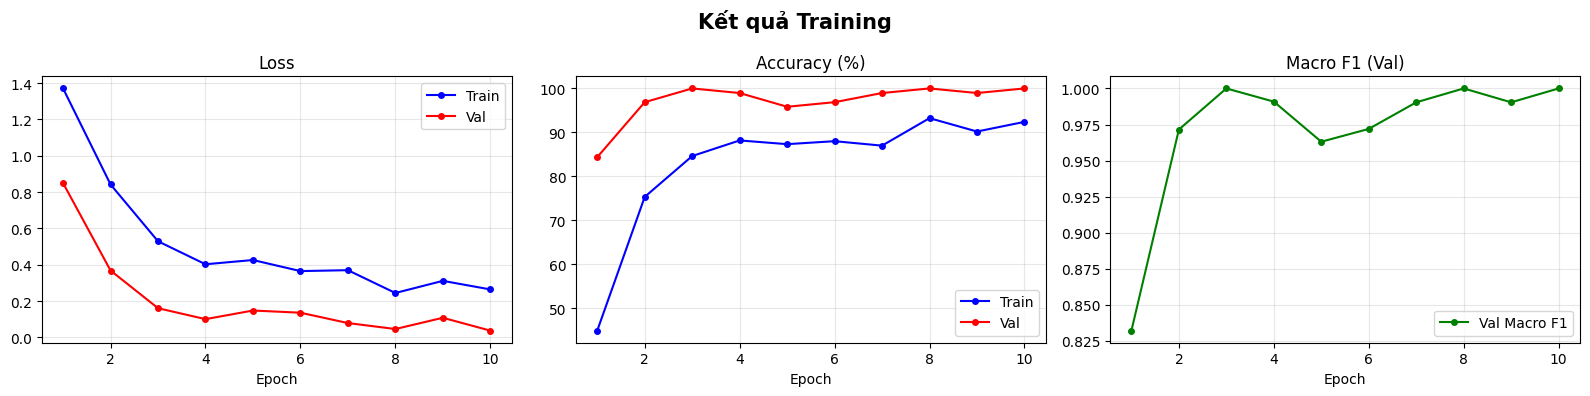

✅ Biểu đồ đã lưu vào Google Drive!


In [13]:
ep = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Kết quả Training', fontsize=15, fontweight='bold')

axes[0].plot(ep, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(ep, history['val_loss'],   'r-o', label='Val',   markersize=4)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['train_acc']], 'b-o', label='Train', markersize=4)
axes[1].plot(ep, [a*100 for a in history['val_acc']],   'r-o', label='Val',   markersize=4)
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, history['val_f1'], 'g-o', label='Val Macro F1', markersize=4)
axes[2].set_title('Macro F1 (Val)'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Biểu đồ đã lưu vào Google Drive!')

## Bước 11: Đánh giá trên tập Test

In [14]:
# Load lại model tốt nhất
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
print('✅ Đã load model tốt nhất!')

test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion)

print('\n' + '=' * 40)
print('🏆 KẾT QUẢ TRÊN TẬP TEST')
print('=' * 40)
print(f'   Test Loss    : {test_loss:.4f}')
print(f'   Test Accuracy: {test_acc*100:.2f}%')
print(f'   Test Macro F1: {test_f1:.4f}')
print('=' * 40)

✅ Đã load model tốt nhất!

🏆 KẾT QUẢ TRÊN TẬP TEST
   Test Loss    : 0.0360
   Test Accuracy: 100.00%
   Test Macro F1: 1.0000


## Bước 12: Confusion Matrix

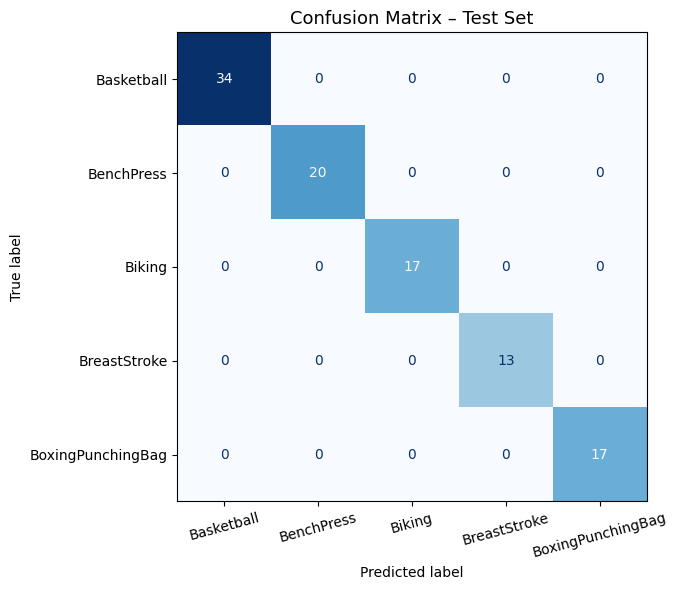

✅ Confusion matrix hoàn tất!


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    preds, labels = [], []
    for frames, lbl in loader:
        frames = frames.to(device)
        preds.extend(model(frames).argmax(1).cpu().numpy())
        labels.extend(lbl.numpy())
    return np.array(labels), np.array(preds)


y_true, y_pred = get_predictions(model, test_loader)

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SELECTED_CLASSES)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=15)
ax.set_title('Confusion Matrix – Test Set', fontsize=13)
plt.tight_layout()
plt.show()
print('✅ Confusion matrix hoàn tất!')

---
## 🎯 Bước 13: Demo – Dự đoán từ file người dùng upload

Phần này dành để **demo khi chấm bài**:
- Upload 1 file **video** hoặc **ảnh** từ máy tính lên Colab
- Model sẽ dự đoán đó là hành động gì
- Hiển thị kết quả rõ ràng: **nhãn dự đoán + độ tin cậy**

> 📌 **Video sẽ cho kết quả hợp lý hơn ảnh**, vì model được train trên chuỗi frame theo thời gian.  
> Nếu upload ảnh, notebook sẽ lặp lại ảnh thành 16 frame để đưa vào model (kết quả mang tính tham khảo).

### 13.1 – Đảm bảo model tốt nhất đã được load

In [16]:
import os
import torch

# Nếu bạn đang chạy phần demo này độc lập (không chạy từ đầu notebook),
# hãy đảm bảo model đã được định nghĩa và SAVE_PATH đúng.
# Nếu đã chạy từ đầu notebook rồi thì bỏ qua cell này.

if os.path.exists(SAVE_PATH):
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model.eval()
    print(f'✅ Đã load model tốt nhất từ: {SAVE_PATH}')
else:
    print('⚠️  Không tìm thấy file model đã lưu.')
    print(f'   Kiểm tra lại đường dẫn: {SAVE_PATH}')
    print('   → Hãy chạy lại phần train trước!')

✅ Đã load model tốt nhất từ: /content/drive/MyDrive/best_model.pth


### 13.2 – Upload file (video hoặc ảnh) và dự đoán

📂 Chọn file để upload (video hoặc ảnh)...
   Nhấn nút "Choose Files" bên dưới để chọn file từ máy tính.



Saving dapxe.mp4 to dapxe.mp4

✅ Đã nhận file: dapxe.mp4  (2728.2 KB)
   → Loại file: VIDEO
   → Đang đọc video và trích xuất frame...
   → Đang dự đoán...


/tmp/ipykernel_3988/103177291.py:87: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


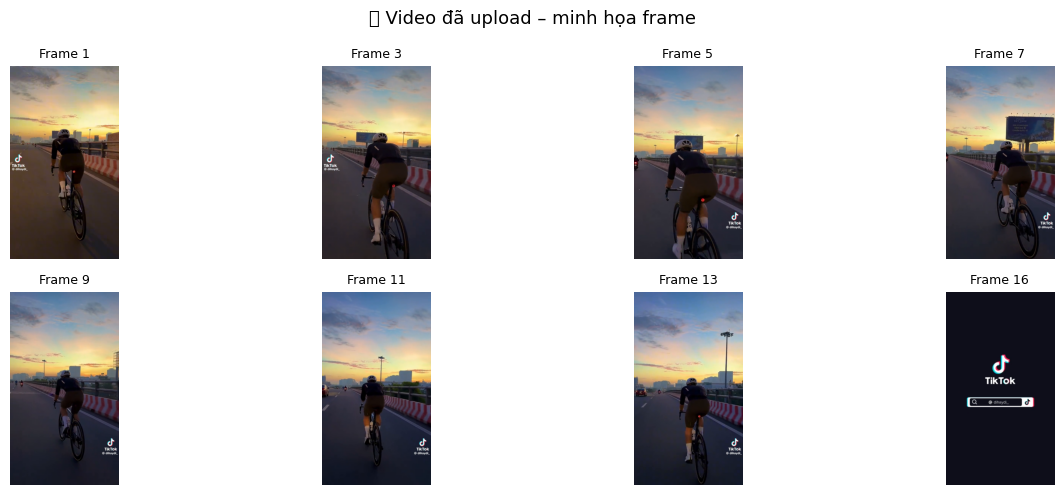

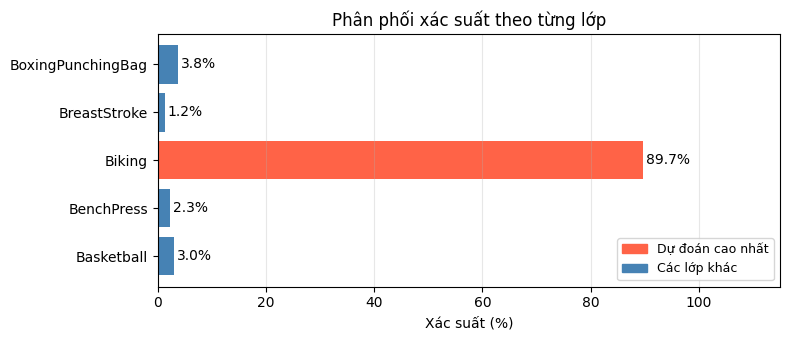


🏆  KẾT QUẢ DỰ ĐOÁN
   Predicted action : Biking
   Confidence       : 89.66%


In [17]:
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
from google.colab import files

# ------------------------------------------------------------------ #
#  Hàm tiền xử lý chung cho cả ảnh và video
# ------------------------------------------------------------------ #

DEMO_TRANSFORM = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])


def frames_from_video(video_path, num_frames=16):
    """Đọc video → trả về (tensor frames, list ảnh RGB để hiển thị)."""
    cap = cv2.VideoCapture(video_path)
    raw = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        raw.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    if len(raw) == 0:
        return None, None

    indices    = np.linspace(0, len(raw) - 1, num_frames, dtype=int)
    tensors    = [DEMO_TRANSFORM(raw[i]) for i in indices]
    preview    = [raw[i] for i in indices]          # ảnh gốc để minh họa
    return torch.stack(tensors), preview


def frames_from_image(image_path, num_frames=16):
    """Đọc ảnh → lặp lại thành num_frames frame (kết quả tham khảo)."""
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    img     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    tensors = [DEMO_TRANSFORM(img)] * num_frames    # lặp lại 16 lần
    preview = [img] * num_frames
    return torch.stack(tensors), preview


@torch.no_grad()
def predict(frame_tensor):
    """
    Nhận tensor (num_frames, 3, H, W).
    Trả về (tên lớp dự đoán, % confidence, list xác suất tất cả lớp).
    """
    model.eval()
    x      = frame_tensor.unsqueeze(0).to(device)   # (1, T, 3, H, W)
    logits = model(x)                               # (1, num_classes)
    probs  = F.softmax(logits, dim=1).squeeze()     # (num_classes,)

    top_idx  = probs.argmax().item()
    top_prob = probs[top_idx].item()
    return idx_to_class[top_idx], top_prob * 100, probs.cpu().numpy()


def show_result(preview_frames, pred_class, confidence, all_probs,
                file_type='video'):
    """Hiển thị 8 frame minh họa và kết quả dự đoán."""

    # ---- Vẽ 8 frame ----
    show_idx = np.linspace(0, len(preview_frames) - 1, 8, dtype=int)
    fig, axes = plt.subplots(2, 4, figsize=(14, 5))
    fig.suptitle(
        f'🎬 {"Video" if file_type=="video" else "Ảnh"} đã upload – minh họa frame',
        fontsize=13
    )
    for ax, idx in zip(axes.flatten(), show_idx):
        ax.imshow(preview_frames[idx])
        ax.set_title(f'Frame {idx+1}', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # ---- Vẽ thanh xác suất tất cả lớp ----
    fig, ax = plt.subplots(figsize=(8, 3.5))
    colors  = ['tomato' if c == pred_class else 'steelblue'
               for c in SELECTED_CLASSES]
    bars    = ax.barh(SELECTED_CLASSES, all_probs * 100, color=colors)

    # Ghi % lên mỗi thanh
    for bar, p in zip(bars, all_probs * 100):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{p:.1f}%', va='center', fontsize=10)

    ax.set_xlim(0, 115)
    ax.set_xlabel('Xác suất (%)')
    ax.set_title('Phân phối xác suất theo từng lớp', fontsize=12)
    legend = [
        mpatches.Patch(color='tomato',    label='Dự đoán cao nhất'),
        mpatches.Patch(color='steelblue', label='Các lớp khác')
    ]
    ax.legend(handles=legend, loc='lower right', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---- In kết quả rõ ràng ----
    print('\n' + '=' * 50)
    print('🏆  KẾT QUẢ DỰ ĐOÁN')
    print('=' * 50)
    print(f'   Predicted action : {pred_class}')
    print(f'   Confidence       : {confidence:.2f}%')
    if file_type == 'image':
        print()
        print('   ℹ️  Lưu ý: Đây là dự đoán từ ảnh tĩnh.')
        print('       Model được train trên video (chuỗi frame),')
        print('       nên kết quả từ video sẽ chính xác hơn.')
    print('=' * 50)


# ================================================================== #
#  MAIN: Upload file và dự đoán
# ================================================================== #

VIDEO_EXTS = {'.avi', '.mp4', '.mov', '.mkv', '.wmv', '.flv'}
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print('📂 Chọn file để upload (video hoặc ảnh)...')
print('   Nhấn nút "Choose Files" bên dưới để chọn file từ máy tính.')
print()

uploaded = files.upload()   # Hiện hộp thoại chọn file

if not uploaded:
    print('⚠️  Không có file nào được upload!')
else:
    for filename, content in uploaded.items():
        ext = os.path.splitext(filename)[1].lower()

        # Lưu file vào /tmp/
        tmp_path = f'/tmp/{filename}'
        with open(tmp_path, 'wb') as f:
            f.write(content)
        print(f'\n✅ Đã nhận file: {filename}  ({len(content)/1024:.1f} KB)')

        # ---- Nhận biết loại file và xử lý ----
        if ext in VIDEO_EXTS:
            print('   → Loại file: VIDEO')
            print('   → Đang đọc video và trích xuất frame...')
            frame_tensor, preview = frames_from_video(tmp_path, NUM_FRAMES)
            file_type = 'video'

        elif ext in IMAGE_EXTS:
            print('   → Loại file: ẢNH')
            print('   → Đang xử lý ảnh (lặp lại thành 16 frame)...')
            frame_tensor, preview = frames_from_image(tmp_path, NUM_FRAMES)
            file_type = 'image'

        else:
            print(f'   ❌ Định dạng không hỗ trợ: {ext}')
            print(f'      Video: {VIDEO_EXTS}')
            print(f'      Ảnh  : {IMAGE_EXTS}')
            continue

        # ---- Kiểm tra đọc file thành công ----
        if frame_tensor is None:
            print('   ❌ Không đọc được file! Thử file khác.')
            continue

        # ---- Dự đoán ----
        print('   → Đang dự đoán...')
        pred_class, confidence, all_probs = predict(frame_tensor)

        # ---- Hiển thị kết quả ----
        show_result(preview, pred_class, confidence, all_probs, file_type)

---
## 📝 Ghi chú & Hướng cải thiện

| Kỹ thuật | Hiệu quả | Cách làm |
|---|---|---|
| Unfreeze ResNet | ⬆️ Accuracy cao hơn | Xóa 2 dòng `param.requires_grad = False` |
| Tăng `NUM_FRAMES` | ⬆️ Nhiều thông tin hơn | Đổi `NUM_FRAMES = 32` |
| Data Augmentation | ⬆️ Giảm overfitting | Thêm `RandomHorizontalFlip`, `ColorJitter` |
| Thêm tầng LSTM | ⬆️ Học sâu hơn | `NUM_LAYERS = 2` |
| Dùng 101 lớp | ⬆️ Bài toán đầy đủ | Bỏ `SELECTED_CLASSES`, lấy tất cả thư mục |

> 💡 Bắt đầu đơn giản, chạy được rồi mới cải thiện từng bước!